# Feb07

In [1]:
# import torch
# import os
# import librosa

# model_scripted_ckpt = "/datab/hungdx/KDW2V-AASISTL/W2V2BASE_AASISTL_DKDLoss_cnsl_audiomentations_3_v10_mobile.pt"
# test_dir = "/datab/hungdx/KDW2V-AASISTL/test_samples/MobileSamples/EnvironmentalSound_mic&screenrecording_trial_5"
# score = "/datab/hungdx/KDW2V-AASISTL/test_samples/MobileSamples/EnvironmentalSound_mic&screenrecording_trial_5/W2V2BASE_AASISTL_DKDLoss_cnsl_audiomentations_3_v10_mobile_trim.txt"
# jit_model = torch.jit.load(model_scripted_ckpt)




In [10]:
import pandas
import sys
import os.path
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import eval_metrics_DF as em
from urllib.parse import urlparse

def is_valid_url(url):
    try:
        result = urlparse(url)
        return all([result.scheme, result.netloc])
    except:
        return False


def extract_domain(url):
    # print("Extracting domain from URL: ", url)

    # Check if the url is not valid url
    if not is_valid_url(url):
        return url


    if not isinstance(url, str):
        return None
    netloc = urlparse(url).netloc
    # If the URL is a short version of youtube URL (e.g., youtu.be), handle it
    if 'youtu.be' in netloc or 'youtube.com' in netloc:
        return 'youtube.com'
    # Extract the domain name (e.g., example.com from https://www.example.com/path)
    # Keep subdomains (e.g., sub.example.com)
    domain = netloc

    # domain = netloc.split('.')[-2] + '.' + netloc.split('.')[-1]
    return domain

def eval_to_score_file(score_file, cm_key_file, meta_file, phase):
    # Load the CM key file and the submission scores
    cm_data = pandas.read_csv(cm_key_file, sep=' ', header=None)
    submission_scores = pandas.read_csv(
        score_file, sep=' ', header=None, skipinitialspace=True)

    # Filter CM data for the specific phase
    cm_scores = submission_scores.merge(
        cm_data[cm_data[1] == phase], left_on=0, right_on=0, how='inner')

    # Check duplicate scores
    cm_scores = cm_scores.drop_duplicates(subset=0)
    
    print("Number of scores for phase {}: {}".format(phase, len(cm_scores)))
    # Load meta data
    meta_data = pandas.read_csv(meta_file, sep=',')

    # Prepare meta_data by concatenating 'eval/' with the 'Utterence name (file name)' to match cm_scores format
    meta_data["file_name"] = 'eval/' + meta_data["utt"] + '.wav'

    # Add a 'domain' column to the meta_data by applying the extract_domain function
    meta_data['domain'] = meta_data['Source link'].apply(extract_domain)

    # Merge cm_scores with meta_data
    merged_data = cm_scores.merge(
        meta_data, left_on=0, right_on="file_name", how='inner')
    
    print("Number of scores for phase {} after merging with meta data: {}".format(phase, len(merged_data)))

    # Now you can group by the "group" column in meta_data for further analysis
    grouped = merged_data.groupby("group")

    # Example of iterating over each group and computing EER for each

    # Get bonafide samples
    bona_cm = merged_data[merged_data[3] == 'bonafide']['1_x'].values
    # Get spoof samples
    spoof_cm = merged_data[merged_data[3] == 'spoof']['1_x'].values

    number_of_bona = len(bona_cm)
    number_of_spoof = len(spoof_cm)

    # Calculate EER
    eer_cm, th = em.compute_eer(bona_cm, spoof_cm)

    out_data = "Group: {}\tnum_bona:{}\tnum_spoof:{}\teer: {}\tthreshold: {}\n".format(
            "Real", number_of_bona, number_of_spoof,  100*eer_cm, th)

    # Draw the confusion matrix
    y_true = np.concatenate((np.zeros(len(bona_cm)), np.ones(len(spoof_cm))))
    y_score = np.concatenate((bona_cm, spoof_cm))

    # Score < th is predicted as spoof (negative class) and score >= th is predicted as bona (positive class)

    cm = confusion_matrix(y_true, y_score < th)

    # Calculate number of false positives, false negatives
    fn = cm[0][1]
    fp = cm[1][0]



    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["bonafide", "spoof"])
    disp.plot()
    plt.title("Group: {}".format("Real"))
    plt.show()

            
    print(out_data)


    group_dict = {}
    for group_name, group_data in grouped:

        bona_cm = group_data[group_data[3] == 'bonafide']['1_x'].values
        spoof_cm = group_data[group_data[3] == 'spoof']['1_x'].values
        
        number_of_bona = len(bona_cm)
        number_of_spoof = len(spoof_cm)

        # Calculate mis classifcation like false positive because we are interested in spoof detection and because we just got bona_cm only

        if len(bona_cm) < 1:
            print("No bonafide samples found for group: {}".format(group_name))
            # Get bonafide samples
            bona_cm = merged_data[merged_data[3] == 'bonafide']['1_x'].values

            # Ensure that bonafide samples are equal to spoof samples
            bona_cm = bona_cm[:len(spoof_cm)]

            number_of_bona = len(bona_cm)


        if len(bona_cm) > 0 and len(spoof_cm) > 0:  # Ensure there's data to compute EER
            eer_cm, th = em.compute_eer(bona_cm, spoof_cm)
            out_data = "Group: {}\tnum_bona:{}\tnum_spoof:{}\teer: {}\tthreshold: {}\n".format(
                group_name, number_of_bona, number_of_spoof,  100*eer_cm, th)

            # Draw the confusion matrix
            y_true = np.concatenate((np.zeros(len(bona_cm)), np.ones(len(spoof_cm))))
            y_score = np.concatenate((bona_cm, spoof_cm))

            # Score < th is predicted as spoof (negative class) and score >= th is predicted as bona (positive class)

            cm = confusion_matrix(y_true, y_score < th)

            # Calculate number of false positives, false negatives
            fn = cm[0][1]
            fp = cm[1][0]



            disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["bonafide", "spoof"])
            disp.plot()
            plt.title("Group: {}".format(group_name))
            plt.show()

            
            print(out_data)
            group_dict[group_name] = [100*eer_cm, th, fp, fn]
        



    # Return value can be adjusted based on your needs
    return group_dict, grouped

Number of scores for phase eval: 41280
Number of scores for phase eval after merging with meta data: 41280


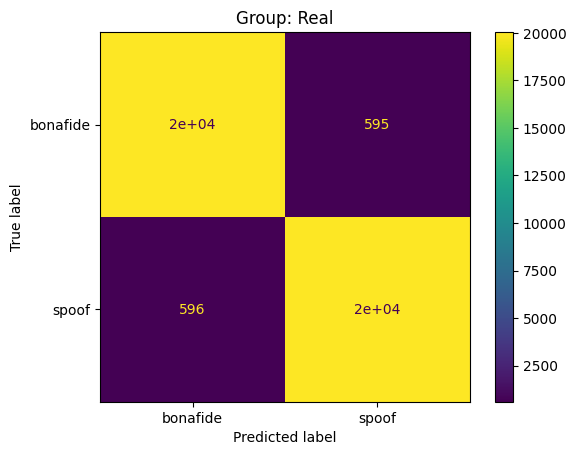

Group: Real	num_bona:20640	num_spoof:20640	eer: 2.8875968992248064	threshold: -1.478115797042847



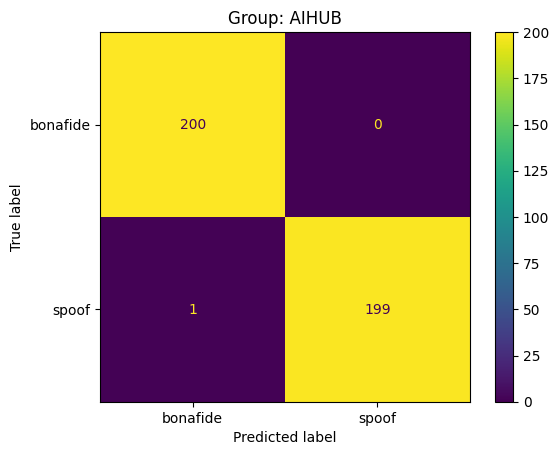

Group: AIHUB	num_bona:200	num_spoof:200	eer: 0.0	threshold: 1.8081035614013672

No bonafide samples found for group: MMSTTS


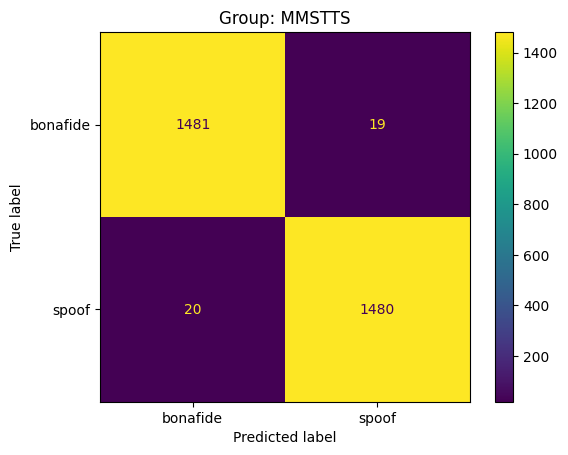

Group: MMSTTS	num_bona:1500	num_spoof:1500	eer: 1.2666666666666666	threshold: -2.0045440196990967

No bonafide samples found for group: OpenVoice-TTS


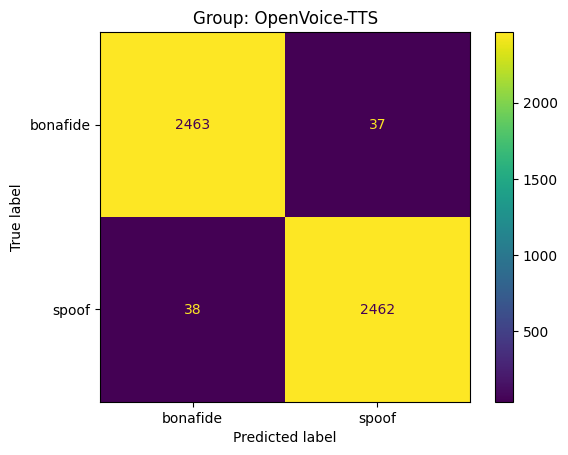

Group: OpenVoice-TTS	num_bona:2500	num_spoof:2500	eer: 1.52	threshold: -1.8577263355255127

No bonafide samples found for group: SeamlessM4T-TTS


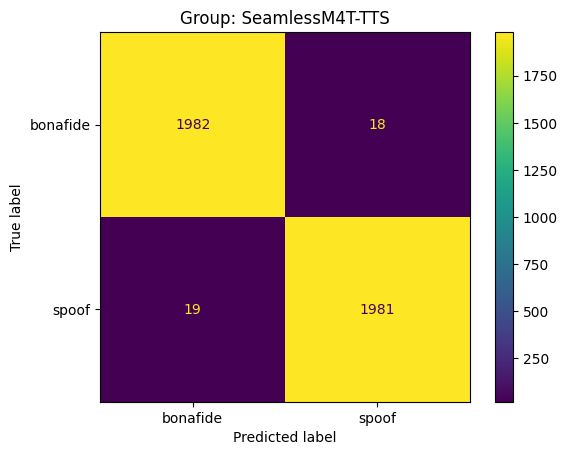

Group: SeamlessM4T-TTS	num_bona:2000	num_spoof:2000	eer: 0.8999999999999999	threshold: -2.166303873062134

No bonafide samples found for group: Tortoise-TTS


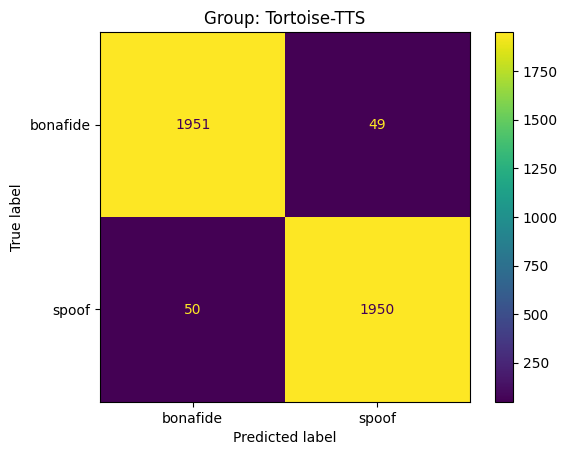

Group: Tortoise-TTS	num_bona:2000	num_spoof:2000	eer: 2.45	threshold: -1.2059555053710938



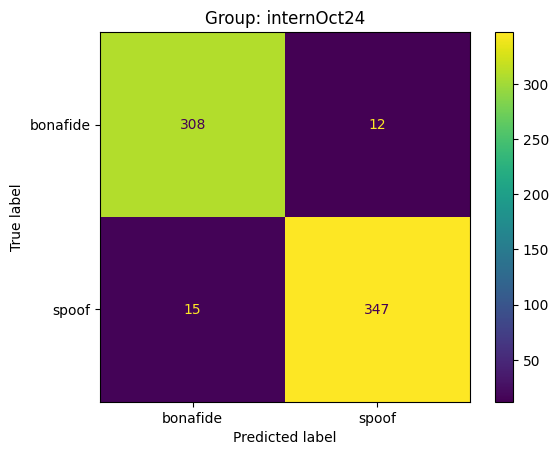

Group: internOct24	num_bona:320	num_spoof:362	eer: 3.8087016574585633	threshold: 1.5829728841781616



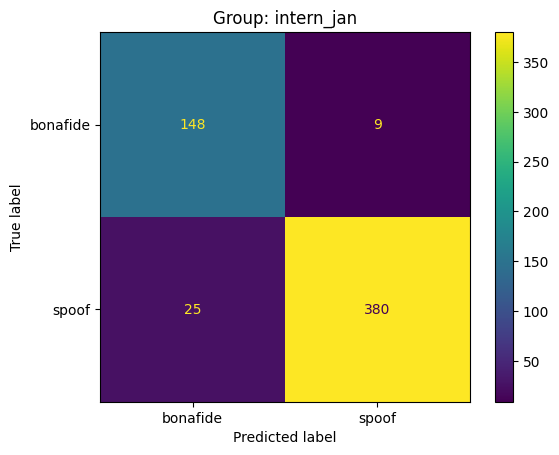

Group: intern_jan	num_bona:157	num_spoof:405	eer: 6.271133128882597	threshold: 1.1648790836334229

No bonafide samples found for group: inthewild_spoof


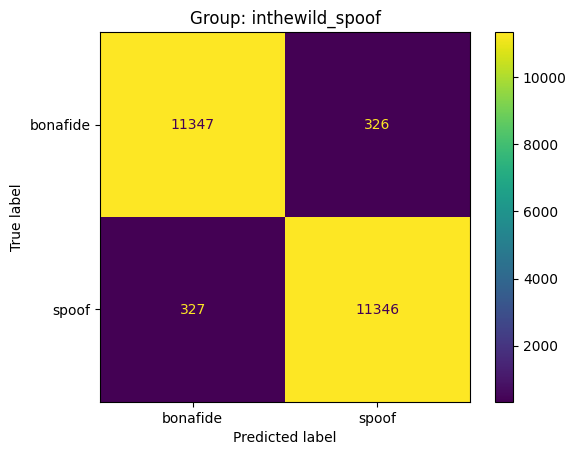

Group: inthewild_spoof	num_bona:11673	num_spoof:11673	eer: 2.7927696393386445	threshold: -1.4769411087036133



In [12]:
score_file = './runs/Distil_XLSR_5_Custom_Trans_Layer_VIB_DKDLoss_MSE_noaudioaug_b16_randomstart_feb07_1_2_3_4_5th_new_hyp_copy_weights_tuning_MSE/best_checkpoint_19.pth.txt'
cm_key_file = '/datab/Dataset/cnsl_real_fake_audio/supcon_cnsl_feb07/protocol.txt'
meta_file = '/datab/Dataset/cnsl_real_fake_audio/supcon_cnsl_feb07/df_meta_feb07.csv'
phase = 'eval'
group_dict, grouped = eval_to_score_file(
    score_file, cm_key_file, meta_file, phase)

## Faster

In [22]:
import sys
import os.path
import numpy as np
import pandas
import eval_metrics_DF as em



def eval_to_score_file(score_file, cm_key_file, meta_file, phase):
    # Load the CM key file and the submission scores
    cm_data = pandas.read_csv(cm_key_file, sep=' ', header=None)
    submission_scores = pandas.read_csv(
        score_file, sep=' ', header=None, skipinitialspace=True)

    # Filter CM data for the specific phase
    cm_scores = submission_scores.merge(
        cm_data[cm_data[1] == phase], left_on=0, right_on=0, how='inner')

    print("Number of scores for phase {}: {}".format(phase, len(cm_scores)))
    # Load meta data
    meta_data = pandas.read_csv(meta_file, sep=',')

    # Prepare meta_data by concatenating 'eval/' with the 'Utterence name (file name)' to match cm_scores format
    meta_data["file_name"] = 'eval/' + meta_data["utt"] + '.wav'

    # Add a 'domain' column to the meta_data by applying the extract_domain function
    meta_data['domain'] = meta_data['Source link'].apply(extract_domain)

    # Merge cm_scores with meta_data
    merged_data = cm_scores.merge(
        meta_data, left_on=0, right_on="file_name", how='inner')
    
    print("Number of scores for phase {} after merging with meta data: {}".format(phase, len(merged_data)))

    # Now you can group by the "group" column in meta_data for further analysis
    grouped = merged_data.groupby("group")

    # Get bonafide samples
    bona_cm = merged_data[merged_data[3] == 'bonafide']['1_x'].values
    # Get spoof samples
    spoof_cm = merged_data[merged_data[3] == 'spoof']['1_x'].values

    number_of_bona = len(bona_cm)
    number_of_spoof = len(spoof_cm)

    # Calculate EER
    eer_cm, th = em.compute_eer(bona_cm, spoof_cm)

    out_data = "Group: {}\tnum_bona:{}\tnum_spoof:{}\teer: {}\tthreshold: {}\n".format(
        "Real", number_of_bona, number_of_spoof,  100*eer_cm, th)

    print(out_data)

    group_dict = {}
    for group_name, group_data in grouped:
        if group_name != 'intern_jan':
            continue
        bona_cm = group_data[group_data[3] == 'bonafide']['1_x'].values
        spoof_cm = group_data[group_data[3] == 'spoof']['1_x'].values

        number_of_bona = len(bona_cm)
        number_of_spoof = len(spoof_cm)
        if len(bona_cm) < 1:
            print("No bonafide samples found for group: {}".format(group_name))
            # Get bonafide samples
            bona_cm = merged_data[merged_data[3] == 'bonafide']['1_x'].values

            # Ensure that bonafide samples are equal to spoof samples
            bona_cm = bona_cm[:len(spoof_cm)]

            number_of_bona = len(bona_cm)

        if len(bona_cm) > 0 and len(spoof_cm) > 0:  # Ensure there's data to compute EER
            eer_cm, th = em.compute_eer(bona_cm, spoof_cm)
            out_data = "Group: {}\tnum_bona:{}\tnum_spoof:{}\teer: {}\tthreshold: {}\n".format(
                group_name, number_of_bona, number_of_spoof,  100*eer_cm, th)

            # Draw the confusion matrix
            y_true = np.concatenate(
                (np.zeros(len(bona_cm)), np.ones(len(spoof_cm))))
            y_score = np.concatenate((bona_cm, spoof_cm))

            # Score < th is predicted as spoof (negative class) and score >= th is predicted as bona (positive class)

            cm = confusion_matrix(y_true, y_score < th)

            # Calculate number of false positives, false negatives
            fn = cm[0][1]
            fp = cm[1][0]

            # disp = ConfusionMatrixDisplay(
            #     confusion_matrix=cm, display_labels=["bonafide", "spoof"])
            # disp.plot()
            # plt.title("Group: {}".format(group_name))
            # plt.show()

            print(out_data)
            group_dict[group_name] = [100*eer_cm, th, fp, fn]

    # Sort group_dict by EER to get min the best performing group first
    

    return group_dict


score_folder = '/datad/hungdx/KDW2V-AASISTL/ablation_study_runs/scores_2s'

for file in os.listdir(score_folder):
    if file.endswith(".txt"):
        print(f"Score file: {file}")
        score_file = os.path.join(score_folder, file)
        cm_key_file = '/datab/Dataset/cnsl_real_fake_audio/supcon_cnsl_feb07/protocol.txt'
        meta_file = '/datab/Dataset/cnsl_real_fake_audio/supcon_cnsl_feb07/df_meta_feb07.csv'
        phase = 'eval'
        eval_to_score_file(
            score_file, cm_key_file, meta_file, phase)

        print("---------------------------------------------------------------------------------------------------------")

Score file: Distil_XLSR_5_Custom_Trans_Layer_VIB_DKDLoss_MSE_noaudioaug_b16_randomstart_feb07_w_o_dkd_best71_feb07_2s.txt
Number of scores for phase eval: 41280
Number of scores for phase eval after merging with meta data: 41280
Group: Real	num_bona:20640	num_spoof:20640	eer: 5.00484496124031	threshold: -3.8931632041931152

Group: intern_jan	num_bona:157	num_spoof:405	eer: 7.648816544782575	threshold: 0.1890910565853119

---------------------------------------------------------------------------------------------------------
Score file: Distil_XLSR_5_Custom_Trans_Layer_VIB_DKDLoss_MSE_noaudioaug_b16_randomstart_feb07_mse_only_best11_feb07_2s.txt
Number of scores for phase eval: 41780
Number of scores for phase eval after merging with meta data: 41780
Group: Real	num_bona:20778	num_spoof:21002	eer: 5.823361028397948	threshold: -2.3136186599731445

Group: intern_jan	num_bona:157	num_spoof:405	eer: 12.100338130062122	threshold: -0.1446894109249115

----------------------------------------

In [5]:
cm_data = pandas.read_csv(cm_key_file, sep=' ', header=None)
submission_scores = pandas.read_csv(
        score_file, sep=' ', header=None, skipinitialspace=True)

# Filter CM data for the specific phase
cm_scores = submission_scores.merge(
        cm_data[cm_data[1] == phase], left_on=0, right_on=0, how='inner')

print("Number of scores for phase {}: {}".format(phase, len(cm_scores)))
    # Load meta data
meta_data = pandas.read_csv(meta_file, sep=',')

    # Prepare meta_data by concatenating 'eval/' with the 'Utterence name (file name)' to match cm_scores format
meta_data["file_name"] = 'eval/' + meta_data["utt"] + '.wav'

    # Add a 'domain' column to the meta_data by applying the extract_domain function
meta_data['domain'] = meta_data['Source link'].apply(extract_domain)

    # Merge cm_scores with meta_data
merged_data = cm_scores.merge(
        meta_data, left_on=0, right_on="file_name", how='inner')

merged_data.head()


def update_pred(row, conf_threshold, domain, group):
    if row['1_x'] < conf_threshold and row['domain'] == domain and row['group'] == group:
        return 'spoof'
    else:
        return 'bonafide'

def is_valid_domain(domain):
    if "." in domain:
        return True
    return False

for key, value in group_dict.items():
    eer, th, fp, fn = value
    print(f"{key} EER: {eer:.2f}%, Threshold: {th:.2f}, False Positive: {fp}, False Negative: {fn}")

    domains = meta_data['domain'].unique()
    if key == 'intern_jan':
        print("False Positive")
        for domain in domains:
            if not is_valid_domain(domain):
                continue
            # Update predictions based on the threshold
            merged_data['pred'] = merged_data.apply(
                update_pred, args=(th, domain, key), axis=1)

            # Calculate false positives and false negatives
            fn = len(merged_data[(merged_data['pred'] == 'spoof') & (merged_data[3] == 'bonafide') & (
                merged_data['domain'] == domain) & (merged_data['group'] == key)])

            fp = len(merged_data[(merged_data['pred'] == 'bonafide') & (merged_data[3] == 'spoof') & (
                merged_data['domain'] == domain) & (merged_data['group'] == key)])

            # Calculate the false positive rate
            group_domain_length = len(
                merged_data[(merged_data['domain'] == domain) & (merged_data['group'] == key)])
            fp_rate = fp / group_domain_length * 100 if group_domain_length != 0 else 0
            fn_rate = fn / group_domain_length * 100 if group_domain_length != 0 else 0

            print(
                f"{domain} -  {fp} - {fp_rate:.2f}%")

        print()

Number of scores for phase eval: 41280
AIHUB EER: 0.00%, Threshold: 1.81, False Positive: 2, False Negative: 0
MMSTTS EER: 1.27%, Threshold: -2.00, False Positive: 40, False Negative: 38
OpenVoice-TTS EER: 3.22%, Threshold: -0.79, False Positive: 161, False Negative: 160
SeamlessM4T-TTS EER: 0.90%, Threshold: -2.17, False Positive: 36, False Negative: 34
Tortoise-TTS EER: 2.95%, Threshold: -0.91, False Positive: 119, False Negative: 118
internOct24 EER: 4.54%, Threshold: 1.90, False Positive: 34, False Negative: 29
intern_jan EER: 6.33%, Threshold: 0.95, False Positive: 51, False Negative: 18
False Positive
youtube.com -  6 - 2.82%
clovadubbing.naver.com -  0 - 0.00%
m.sports.naver.com -  0 - 0.00%
app.typecast.ai -  0 - 0.00%
media.naver.com -  0 - 0.00%
elevenlabs.io -  14 - 11.20%
studio.neiro.ai -  0 - 0.00%
www.facebook.com -  0 - 0.00%
app.resemble.ai -  0 - 0.00%
webapp.dubverse.ai -  0 - 0.00%
grad-tts.github.io -  0 - 0.00%
nbviewer.org -  0 - 0.00%
styletts2.github.io -  0 - 

# In the wild

In [6]:
import sys
import os.path
import numpy as np
import pandas
import eval_metrics_DF as em


def eval_to_score_file(score_file, cm_key_file):
    # CM key file is the metadata file that contains the ground truth labels for the eval set
    # score file is the output of the system that contains the scores for the eval set
    # phase is the phase of the eval set (dev or eval)

    cm_data = pandas.read_csv(cm_key_file, sep=' ', header=None)
    submission_scores = pandas.read_csv(
        score_file, sep=' ', header=None, skipinitialspace=True)
    # check here for progress vs eval set
    cm_scores = submission_scores.merge(cm_data, left_on=0, right_on=0, how='inner')
    # cm_scores.head()
    #  0       1_x   1_y      2      3
    #  a.wav  1.234   eval   Music   spoof
    bona_cm = cm_scores[cm_scores['1_y'] == 'bonafide']['1_x'].values
    spoof_cm = cm_scores[cm_scores['1_y'] == 'spoof']['1_x'].values

    eer_cm, th = em.compute_eer(bona_cm, spoof_cm)
    out_data = "eer: {}\tthreshold: {}\n".format(100*eer_cm, th)
    print(out_data)
    return eer_cm

In [7]:
score_file = './W2V2BASE_Linear_DKDLoss_cnsl_noaudiomentations_best39_in_the_wild.txt'
cm_key_file = '/datab/Dataset/cnsl_real_fake_audio/in_the_wild.txt'



eval_to_score_file(score_file, cm_key_file)

FileNotFoundError: [Errno 2] No such file or directory: './W2V2BASE_Linear_DKDLoss_cnsl_noaudiomentations_best39_in_the_wild.txt'

# Eval Feb07

In [ ]:
import os
import sys
import os.path
import numpy as np
import pandas
import eval_metrics_DF as em

def eval_to_score_file(score_file, cm_key_file, phase):
    # CM key file is the metadata file that contains the ground truth labels for the eval set
    # score file is the output of the system that contains the scores for the eval set
    # phase is the phase of the eval set (dev or eval)

    cm_data = pandas.read_csv(cm_key_file, sep=' ', header=None)
    submission_scores = pandas.read_csv(
        score_file, sep=' ', header=None, skipinitialspace=True)
    # check here for progress vs eval set
    cm_scores = submission_scores.merge(
        cm_data[cm_data[1] == phase], left_on=0, right_on=0, how='inner')
    # cm_scores.head()
    #  0       1_x   1_y      2      3
    #  a.wav  1.234   eval   Music   spoof
    bona_cm = cm_scores[cm_scores[3] == 'bonafide']['1_x'].values
    spoof_cm = cm_scores[cm_scores[3] == 'spoof']['1_x'].values

    max_score = max(cm_scores['1_x'].values)
    min_score = min(cm_scores['1_x'].values)

    print("max score: ", max_score)
    print("min score: ", min_score)

    eer_cm, th = em.compute_eer(bona_cm, spoof_cm)
    out_data = "eer: {}\tthreshold: {}\n".format(100*eer_cm, th)
    print(out_data)
    return eer_cm


dir_path = '/datad/hungdx/KDW2V-AASISTL/models/W2V2BASE_VIB_DKDLoss_noaudioaug_b16_randomstart_CosineAnnealingWarmRestarts_acmccs_apr3'
cm_key_file = '/home/hungdx/Datasets/supcon_cnsl_feb07/protocol.txt'


def get_score_files_in_dir(dir_path):
    score_files = []
    for root, dirs, files in os.walk(dir_path):
        for file in files:
            if file.endswith(".txt"):
                score_files.append(os.path.join(root, file))
    return score_files


score_files = get_score_files_in_dir(dir_path)
print(score_files)

for score_file in score_files:
    print("Score file: ", score_file)
    eval_to_score_file(score_file, cm_key_file, 'eval')

['/datad/hungdx/KDW2V-AASISTL/models/W2V2BASE_VIB_DKDLoss_noaudioaug_b16_randomstart_CosineAnnealingWarmRestarts_acmccs_apr3/best_checkpoint_2.pth_eval_morekore.txt', '/datad/hungdx/KDW2V-AASISTL/models/W2V2BASE_VIB_DKDLoss_noaudioaug_b16_randomstart_CosineAnnealingWarmRestarts_acmccs_apr3/best_checkpoint_31.pth_eval_morekore.txt', '/datad/hungdx/KDW2V-AASISTL/models/W2V2BASE_VIB_DKDLoss_noaudioaug_b16_randomstart_CosineAnnealingWarmRestarts_acmccs_apr3/best_checkpoint_15.pth_eval_morekore.txt', '/datad/hungdx/KDW2V-AASISTL/models/W2V2BASE_VIB_DKDLoss_noaudioaug_b16_randomstart_CosineAnnealingWarmRestarts_acmccs_apr3/best_checkpoint_7.pth_eval_morekore.txt', '/datad/hungdx/KDW2V-AASISTL/models/W2V2BASE_VIB_DKDLoss_noaudioaug_b16_randomstart_CosineAnnealingWarmRestarts_acmccs_apr3/best_checkpoint_6.pth_eval_morekore.txt', '/datad/hungdx/KDW2V-AASISTL/models/W2V2BASE_VIB_DKDLoss_noaudioaug_b16_randomstart_CosineAnnealingWarmRestarts_acmccs_apr3/best_checkpoint_13.pth_eval_morekore.txt', 

# Eval MoreKor

In [ ]:
import sys
import os.path
import numpy as np
import pandas
import eval_metrics_DF as em


def eval_to_score_file(score_file, cm_key_file, phase):
    # CM key file is the metadata file that contains the ground truth labels for the eval set
    # score file is the output of the system that contains the scores for the eval set
    # phase is the phase of the eval set (dev or eval)

    cm_data = pandas.read_csv(cm_key_file, sep=' ', header=None)
    # print(cm_data.head())
    submission_scores = pandas.read_csv(
        score_file, sep=' ', header=None, skipinitialspace=True)
    # check here for progress vs eval set
    cm_scores = submission_scores.merge(
        cm_data[cm_data[2] == phase], left_on=0, right_on=0, how='inner')
    print(cm_scores.head())
    # cm_scores.head()
    #  0       1_x   1_y      2      3
    #  a.wav  1.234   eval   Music   spoof
    bona_cm = cm_scores[cm_scores['1_y'] == 'bonafide']['1_x'].values
    spoof_cm = cm_scores[cm_scores['1_y'] == 'spoof']['1_x'].values

    max_score = max(cm_scores['1_x'].values)
    min_score = min(cm_scores['1_x'].values)

    print("max score: ", max_score)
    print("min score: ", min_score)

    eer_cm, th = em.compute_eer(bona_cm, spoof_cm)
    out_data = "eer: {}\tthreshold: {}\n".format(100*eer_cm, th)
    print(out_data)
    return eer_cm


In [ ]:
score_file = '/datad/hungdx/SSL_Anti-spoofing/models/model_DF_weighted_CCE_100_14_1e-06_ACMCCS_flow/trainset_ACMCCS_eval_on_ACMCCS_flow_best_checkpoint_81.txt'
cm_key_file = '/datab/Dataset/cnsl_real_fake_audio/ACMCCS/protocol_diff.txt'
eval_to_score_file(score_file, cm_key_file, 'eval')

                                0       1_x    1_y     2
0  SeamlessM4T-TTS_deu_000140.wav  4.749841  spoof  eval
1  SeamlessM4T-TTS_eng_000084.wav  4.428932  spoof  eval
2  SeamlessM4T-TTS_fra_000056.wav  4.876781  spoof  eval
3  SeamlessM4T-TTS_kor_000004.wav  4.012679  spoof  eval
4  SeamlessM4T-TTS_arb_000037.wav  4.601263  spoof  eval
max score:  5.141388893127441
min score:  -4.876585960388184
eer: 35.642508280562936	threshold: 4.274649620056152



0.35642508280562935

In [ ]:
import os
dir_path = '/datad/hungdx/KDW2V-AASISTL/models/W2V2BASE_VIB_DKDLoss_noaudioaug_b16_randomstart_CosineAnnealingWarmRestarts_acmccs_apr3/best_checkpoint_0.pth_eval_morekore.txt'
cm_key_file = '/datad/Datasets/moreko/protocol.txt'
def get_score_files_in_dir(dir_path):
    score_files = []
    for root, dirs, files in os.walk(dir_path):
        for file in files:
            if file.endswith(".txt"):
                score_files.append(os.path.join(root, file))
    return score_files

score_files = get_score_files_in_dir(dir_path)
print(score_files)

for score_file in score_files:
    print("Score file: ", score_file)
    eval_to_score_file(score_file, cm_key_file, 'eval')

['/datad/hungdx/KDW2V-AASISTL/models/W2V2BASE_VIB_DKDLoss_noaudioaug_b16_randomstart_CosineAnnealingWarmRestarts_acmccs_apr3_feb07_from_W2V2BASE_VIB_DKDLoss_noaudioaug_b16_randomstart_CosineAnnealingWarmRestarts_acmccs_apr3_moreko/best_checkpoint_2.pth_eval_morekore.txt', '/datad/hungdx/KDW2V-AASISTL/models/W2V2BASE_VIB_DKDLoss_noaudioaug_b16_randomstart_CosineAnnealingWarmRestarts_acmccs_apr3_feb07_from_W2V2BASE_VIB_DKDLoss_noaudioaug_b16_randomstart_CosineAnnealingWarmRestarts_acmccs_apr3_moreko/best_checkpoint_9.pth_eval_morekore.txt', '/datad/hungdx/KDW2V-AASISTL/models/W2V2BASE_VIB_DKDLoss_noaudioaug_b16_randomstart_CosineAnnealingWarmRestarts_acmccs_apr3_feb07_from_W2V2BASE_VIB_DKDLoss_noaudioaug_b16_randomstart_CosineAnnealingWarmRestarts_acmccs_apr3_moreko/best_checkpoint_17.pth_eval_morekore.txt', '/datad/hungdx/KDW2V-AASISTL/models/W2V2BASE_VIB_DKDLoss_noaudioaug_b16_randomstart_CosineAnnealingWarmRestarts_acmccs_apr3_feb07_from_W2V2BASE_VIB_DKDLoss_noaudioaug_b16_randomstart